# CNN Classification with PyTorch (SimplicityDB)

1. Load and split the dataset into **train / validation / test**
2. Apply **data augmentation** to the training set
3. Train **multiple CNN configurations**
4. Compare all models in **one summary table**
5. Select the best configuration using **validation accuracy**
6. Evaluate the best model on the **test set**
7. Analyze errors with:
   - confusion matrix
   - classification report
   - misclassified examples


## Import libraries

In [1]:

import os
import zipfile
import copy
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


## 2. Reproducibility and device

In [2]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Extract dataset

In [3]:

zip_path = "./SimplicityDB.zip"
extract_dir = "./SimplicityDB"

if os.path.exists(zip_path) and not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")
    print(f"Extracted dataset to {extract_dir}")
else:
    print("Dataset already extracted or zip file not found.")


Dataset already extracted or zip file not found.


## Define transforms

- **training augmentation**: random resized crop, horizontal flip, small rotation, color jitter
- **validation/test transforms**: deterministic resize and normalization

To apply augmentation only to the training split, I created separate datasets for train and eval and use the same indices after splitting.


In [4]:

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2 if os.name != "nt" else 0

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## Load datasets and create train/validation/test loaders

In [5]:

train_root = os.path.join(extract_dir, "train")
test_root  = os.path.join(extract_dir, "test")

full_train_aug = datasets.ImageFolder(train_root, transform=train_transform)
full_train_eval = datasets.ImageFolder(train_root, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_root, transform=eval_transform)

class_names = full_train_aug.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training images:", len(full_train_aug))
print("Test images:", len(test_dataset))


Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Number of classes: 10
Training images: 700
Test images: 300


In [6]:
# 80% train, 20% validation
train_len = int(0.8 * len(full_train_aug))
val_len = len(full_train_aug) - train_len

generator = torch.Generator().manual_seed(SEED)
train_subset_aug, val_subset_aug = random_split(full_train_aug, [train_len, val_len], generator=generator)

# Re-create subsets on the evaluation transform so validation has no augmentation
train_indices = train_subset_aug.indices
val_indices = val_subset_aug.indices

train_dataset = Subset(full_train_aug, train_indices)
val_dataset = Subset(full_train_eval, val_indices)

trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
valloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
testloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")
print(f"Test size:  {len(test_dataset)}")


Train size: 560
Val size:   140
Test size:  300


## Visualize augmented training samples

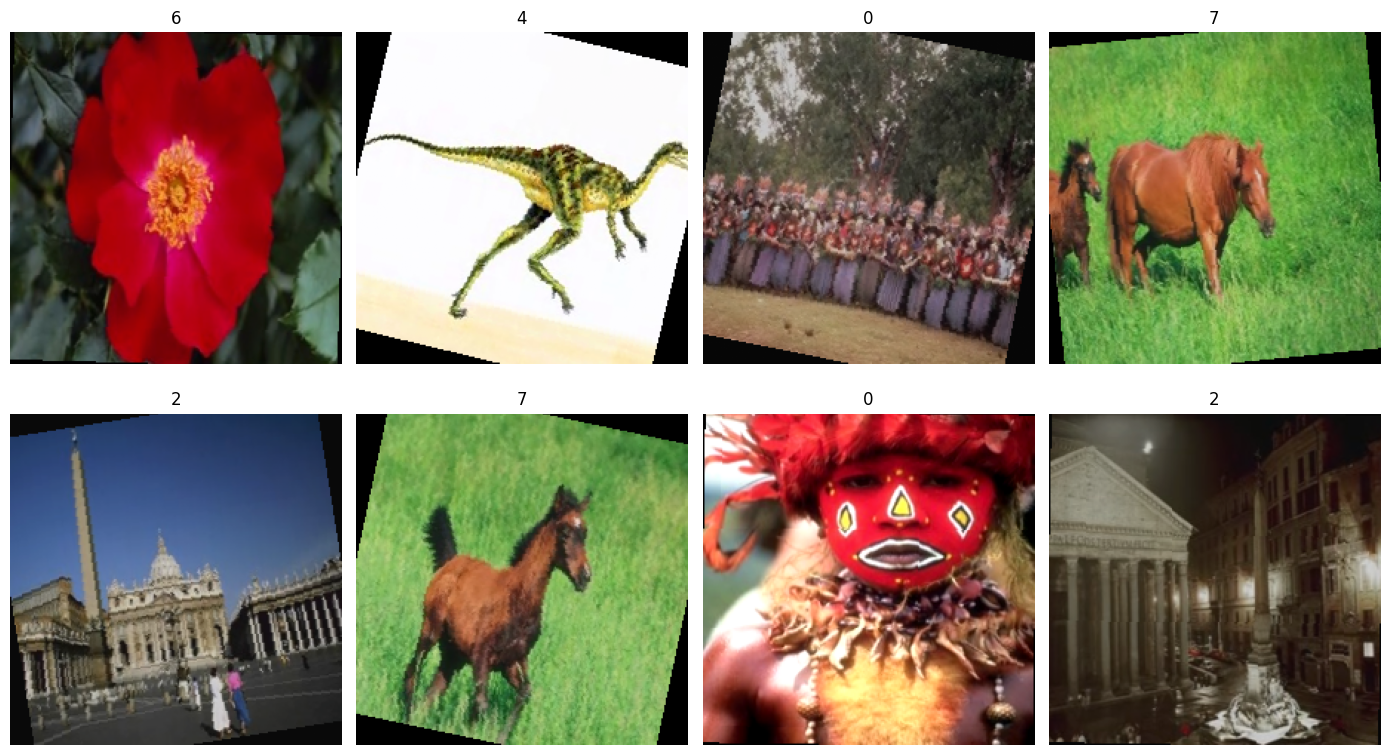

In [7]:

def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean

images, labels = next(iter(trainloader))
plt.figure(figsize=(14, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i].cpu()).clamp(0, 1)
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(class_names[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()


## Define a configurable CNN

- number of convolutional blocks (**depth**)
- number of filters (**width / capacity**)
- dropout
- optimizer
- learning rate
- weight decay

Each convolutional block contains:
- Conv2d
- BatchNorm2d
- ReLU
- optional MaxPool2d

The classifier uses adaptive average pooling so it does **not** depend on a hardcoded image size.


In [ ]:

# class ResidualBlock(nn.Module):
#     def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
#         super().__init__()
#         self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm2d(out_ch)
#         self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn2 = nn.BatchNorm2d(out_ch)
#         self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

#         if stride != 1 or in_ch != out_ch:
#             self.shortcut = nn.Sequential(
#                 nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
#                 nn.BatchNorm2d(out_ch),
#             )
#         else:
#             self.shortcut = nn.Identity()

#     def forward(self, x):
#         identity = self.shortcut(x)
#         out = torch.relu(self.bn1(self.conv1(x)))
#         out = self.dropout(out)
#         out = self.bn2(self.conv2(out))
#         out = torch.relu(out + identity)
#         return out

# class StrongCustomCNN(nn.Module):
#     def __init__(self, num_classes=10, dropout=0.20):
#         super().__init__()
#         self.stem = nn.Sequential(
#             nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
#         )
#         self.layer1 = nn.Sequential(ResidualBlock(32, 32, dropout=dropout), ResidualBlock(32, 32, dropout=dropout), nn.MaxPool2d(2))
#         self.layer2 = nn.Sequential(ResidualBlock(32, 64, dropout=dropout), ResidualBlock(64, 64, dropout=dropout), nn.MaxPool2d(2))
#         self.layer3 = nn.Sequential(ResidualBlock(64, 128, dropout=dropout), ResidualBlock(128, 128, dropout=dropout), nn.MaxPool2d(2))
#         self.layer4 = nn.Sequential(ResidualBlock(128, 256, dropout=dropout), ResidualBlock(256, 256, dropout=dropout), nn.MaxPool2d(2))
#         self.pool = nn.AdaptiveAvgPool2d((1, 1))
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(256, 256),
#             nn.ReLU(inplace=True),
#             nn.Dropout(0.30),
#             nn.Linear(256, num_classes),
#         )

#     def forward(self, x):
#         x = self.stem(x)
#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)
#         x = self.layer4(x)
#         x = self.pool(x)
#         x = self.classifier(x)
#         return x


# def build_model(model_name, num_classes):
#     model_name = model_name.lower()

#     if model_name == 'custom_cnn':
#         return StrongCustomCNN(num_classes=num_classes)

#     if model_name == 'resnet18':
#         model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#         model.fc = nn.Linear(model.fc.in_features, num_classes)
#         return model

#     if model_name == 'efficientnet_b0':
#         model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
#         model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
#         return model

#     raise ValueError(f'Unknown model name: {model_name}')


In [ ]:

# experiment_configs = [
#     {
#         'name': 'custom_cnn',
#         'epochs': 20,
#         'lr': 1e-3,
#         'weight_decay': 1e-4,
#         'label_smoothing': 0.05,
#         'early_stopping_patience': 3,
#         'warmup_head_only': False,
#     },
#       {
#         "name": "baseline_small_adam",
#         "channels": (32, 64, 128, 256, 512),
#         "dropout": 0.1,
#         "lr": 1e-3,
#         "weight_decay": 1e-4,
#         "optimizer": "adam",
#         "epochs": 20,
#     },
#     {
#         "name": "deeper_medium_adam",
#         "channels": (32, 64, 128, 256),
#         "dropout": 0.30,
#         "lr": 8e-4,
#         "weight_decay": 1e-4,
#         "optimizer": "adam",
#         "epochs": 20,
#     },
#     {
#         "name": "wider_adam",
#         "channels": (64, 128, 256, 256),
#         "dropout": 0.35,
#         "lr": 7e-4,
#         "weight_decay": 1e-4,
#         "optimizer": "adam",
#         "epochs": 20,
#     },
#     {
#         "name": "deeper_sgd",
#         "channels": (32, 64, 128, 256),
#         "dropout": 0.30,
#         "lr": 1e-2,
#         "weight_decay": 5e-4,
#         "optimizer": "sgd",
#         "epochs": 20,
#     },
    
#     {
#         'name': 'resnet18',
#         'epochs': 20,
#         'lr': 1e-3,
#         'fine_tune_lr': 2e-4,
#         'weight_decay': 1e-4,
#         'label_smoothing': 0.1,
#         'early_stopping_patience': 3,
#         'warmup_head_only': True,
#     },
#     {
#         'name': 'efficientnet_b0',
#         'epochs': 20,
#         'lr': 8e-4,
#         'fine_tune_lr': 1.5e-4,
#         'weight_decay': 1e-4,
#         'label_smoothing': 0.1,
#         'early_stopping_patience': 3,
#         'warmup_head_only': True,
#     },  
# ]

# experiment_configs
# # 

In [8]:

class ConfigurableCNN(nn.Module):
    def __init__(self, num_classes=10, conv_channels=(32, 64, 128), dropout=0.3, fc_units=256):
        super().__init__()

        layers = []
        in_channels = 3

        for i, out_channels in enumerate(conv_channels):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))

            # Add a second conv in deeper stages for richer features
            if i >= 1:
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1))
                layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU(inplace=True))

            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            layers.append(nn.Dropout2d(p=min(dropout, 0.35)))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_channels[-1], fc_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_units, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


## Training and evaluation utilities

In [9]:

def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    all_labels = []
    all_preds = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

def build_optimizer(model, config):
    opt_name = config["optimizer"].lower()
    lr = config["lr"]
    weight_decay = config.get("weight_decay", 0.0)

    if opt_name == "adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif opt_name == "adamw":
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")

def count_conv_layers(model):
    return sum(1 for m in model.modules() if isinstance(m, nn.Conv2d))

def train_experiment(config, trainloader, valloader, device, num_classes, epochs=20, patience=5):
    model = ConfigurableCNN(
        num_classes=num_classes,
        conv_channels=config["conv_channels"],
        dropout=config["dropout"],
        fc_units=config["fc_units"]
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, config)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }

    best_state = None
    best_val_acc = -1.0
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate_model(model, valloader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        improved = (val_acc > best_val_acc) or (val_acc == best_val_acc and val_loss < best_val_loss)
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"[{config['name']}] Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping for {config['name']} after epoch {epoch+1}")
            break

    model.load_state_dict(best_state)

    result = {
        "name": config["name"],
        "num_conv_layers": count_conv_layers(model),
        "conv_channels": str(config["conv_channels"]),
        "dropout": config["dropout"],
        "fc_units": config["fc_units"],
        "optimizer": config["optimizer"],
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "epochs_ran": len(history["val_acc"]),
        "history": history,
        "model_state_dict": copy.deepcopy(model.state_dict())
    }
    return result


## Experiment configurations

I varied:
- **number of CNN layers**
- **number of filters**
- **dropout**
- **optimizer**
- **learning rate**
- **weight decay**

This gives a meaningful comparison across different network parameter settings.


In [21]:
EXPERIMENTS = [
    {
        "name": "CNN_3_layers_small_adam",
        "conv_channels": (32, 64, 128),
        "dropout": 0.30,
        "fc_units": 256,
        "optimizer": "adam",
        "lr": 1e-3,
        "weight_decay": 1e-4
    },
    {
        "name": "CNN_3_layers_wider_adam",
        "conv_channels": (64, 128, 256),
        "dropout": 0.30,
        "fc_units": 256,
        "optimizer": "adam",
        "lr": 8e-4,
        "weight_decay": 1e-4
    },
    {
        "name": "CNN_4_layers_medium_adam",
        "conv_channels": (32, 64, 128, 256),
        "dropout": 0.35,
        "fc_units": 256,
        "optimizer": "adam",
        "lr": 8e-4,
        "weight_decay": 1e-4
    },
    {
        "name": "CNN_4_layers_wider_adamw",
        "conv_channels": (64, 128, 256, 256),
        "dropout": 0.40,
        "fc_units": 256,
        "optimizer": "adamw",
        "lr": 7e-4,
        "weight_decay": 5e-4
    },
    {
        "name": "CNN_4_layers_medium_sgd",
        "conv_channels": (32, 64, 128, 256),
        "dropout": 0.30,
        "fc_units": 256,
        "optimizer": "sgd",
        "lr": 1e-2,
        "weight_decay": 1e-4
    },
    {
        "name": "CNN_5_layers_deep_adam",
        "conv_channels": (32, 64, 128, 256, 256),
        "dropout": 0.40,
        "fc_units": 256,
        "optimizer": "adam",
        "lr": 7e-4,
        "weight_decay": 1e-4
    },
    {
        "name": "CNN_5_layers_deep_sgd",
        "conv_channels": (32, 64, 128, 256, 256),
        "dropout": 0.35,
        "fc_units": 256,
        "optimizer": "sgd",
        "lr": 1e-2,
        "weight_decay": 1e-4
    },
    {
        "name": "CNN_5_layers_wider_adamw",
        "conv_channels": (64, 128, 256, 256, 512),
        "dropout": 0.45,
        "fc_units": 512,
        "optimizer": "adamw",
        "lr": 5e-4,
        "weight_decay": 5e-4
    },
    {
        "name": "CNN_6_layers_compact_adam",
        "conv_channels": (32, 64, 128, 128, 256, 256),
        "dropout": 0.35,
        "fc_units": 256,
        "optimizer": "adam",
        "lr": 6e-4,
        "weight_decay": 1e-4
    },
    {
        "name": "CNN_6_layers_large_adamw",
        "conv_channels": (64, 128, 128, 256, 256, 512),
        "dropout": 0.45,
        "fc_units": 512,
        "optimizer": "adamw",
        "lr": 4e-4,
        "weight_decay": 7e-4
    }
]

pd.DataFrame(EXPERIMENTS)

,name,conv_channels,dropout,fc_units,optimizer,lr,weight_decay
0,CNN_3_layers_small_adam,"(32, 64, 128)",0.30,256,adam,0.0010,0.0001
1,CNN_3_layers_wider_adam,"(64, 128, 256)",0.30,256,adam,0.0008,0.0001
2,CNN_4_layers_medium_adam,"(32, 64, 128, 256)",0.35,256,adam,0.0008,0.0001
3,CNN_4_layers_wider_adamw,"(64, 128, 256, 256)",0.40,256,adamw,0.0007,0.0005
4,CNN_4_layers_medium_sgd,"(32, 64, 128, 256)",0.30,256,sgd,0.0100,0.0001
5,CNN_5_layers_deep_adam,"(32, 64, 128, 256, 256)",0.40,256,adam,0.0007,0.0001
6,CNN_5_layers_deep_sgd,"(32, 64, 128, 256, 256)",0.35,256,sgd,0.0100,0.0001
7,CNN_5_layers_wider_adamw,"(64, 128, 256, 256, 512)",0.45,512,adamw,0.0005,0.0005
8,CNN_6_layers_compact_adam,"(32, 64, 128, 128, 256, 256)",0.35,256,adam,0.0006,0.0001
9,CNN_6_layers_large_adamw,"(64, 128, 128, 256, 256, 512)",0.45,512,adamw,0.0004,0.0007


## Run all experiments

In [22]:

EPOCHS = 20
PATIENCE = 5

all_results = []

for config in EXPERIMENTS:
    result = train_experiment(
        config=config,
        trainloader=trainloader,
        valloader=valloader,
        device=device,
        num_classes=num_classes,
        epochs=EPOCHS,
        patience=PATIENCE
    )
    all_results.append(result)


[CNN_3_layers_small_adam] Epoch 01/20 | Train Loss: 2.1507 | Train Acc: 0.2196 | Val Loss: 1.7285 | Val Acc: 0.4429
[CNN_3_layers_small_adam] Epoch 02/20 | Train Loss: 1.7791 | Train Acc: 0.3911 | Val Loss: 1.2686 | Val Acc: 0.5857
[CNN_3_layers_small_adam] Epoch 03/20 | Train Loss: 1.5936 | Train Acc: 0.4179 | Val Loss: 1.1111 | Val Acc: 0.7143
[CNN_3_layers_small_adam] Epoch 04/20 | Train Loss: 1.4940 | Train Acc: 0.4714 | Val Loss: 0.9720 | Val Acc: 0.7000
[CNN_3_layers_small_adam] Epoch 05/20 | Train Loss: 1.3556 | Train Acc: 0.5161 | Val Loss: 1.0561 | Val Acc: 0.6286
[CNN_3_layers_small_adam] Epoch 06/20 | Train Loss: 1.3353 | Train Acc: 0.4964 | Val Loss: 0.9098 | Val Acc: 0.7357
[CNN_3_layers_small_adam] Epoch 07/20 | Train Loss: 1.2638 | Train Acc: 0.5179 | Val Loss: 0.8287 | Val Acc: 0.7643
[CNN_3_layers_small_adam] Epoch 08/20 | Train Loss: 1.2607 | Train Acc: 0.5429 | Val Loss: 0.8432 | Val Acc: 0.7429
[CNN_3_layers_small_adam] Epoch 09/20 | Train Loss: 1.2254 | Train Acc: 

## The performance of all varieties in one

In [23]:
results_table = pd.DataFrame([
    {
        "Rank": idx + 1,
        "Model": r["name"],
        "Conv Layers": r["num_conv_layers"],
        "Conv Channels": r["conv_channels"],
        "Dropout": r["dropout"],
        "FC Units": r["fc_units"],
        "Optimizer": r["optimizer"],
        "Learning Rate": r["lr"],
        "Weight Decay": r["weight_decay"],
        "Best Val Accuracy (%)": round(r["best_val_acc"] * 100, 2),
        "Best Val Loss": round(r["best_val_loss"], 4),
        "Epochs Ran": r["epochs_ran"]
    }
    for idx, r in enumerate(sorted(all_results, key=lambda x: x["best_val_acc"], reverse=True))
]).reset_index(drop=True)

results_table

,Rank,Model,Conv Layers,Conv Channels,Dropout,FC Units,Optimizer,Learning Rate,Weight Decay,Best Val Accuracy (%),Best Val Loss,Epochs Ran
0,1,CNN_6_layers_large_adamw,11,"(64, 128, 128, 256, 256, 512)",0.45,512,adamw,0.0004,0.0007,86.43,0.5132,20
1,2,CNN_4_layers_wider_adamw,7,"(64, 128, 256, 256)",0.40,256,adamw,0.0007,0.0005,82.86,0.5719,20
2,3,CNN_3_layers_small_adam,5,"(32, 64, 128)",0.30,256,adam,0.0010,0.0001,82.14,0.6550,20
3,4,CNN_4_layers_medium_adam,7,"(32, 64, 128, 256)",0.35,256,adam,0.0008,0.0001,81.43,0.7561,14
4,5,CNN_3_layers_wider_adam,5,"(64, 128, 256)",0.30,256,adam,0.0008,0.0001,80.00,0.6869,11
5,6,CNN_5_layers_wider_adamw,9,"(64, 128, 256, 256, 512)",0.45,512,adamw,0.0005,0.0005,80.00,0.6448,19
6,7,CNN_4_layers_medium_sgd,7,"(32, 64, 128, 256)",0.30,256,sgd,0.0100,0.0001,79.29,0.7090,17
7,8,CNN_6_layers_compact_adam,11,"(32, 64, 128, 128, 256, 256)",0.35,256,adam,0.0006,0.0001,79.29,0.7368,20
8,9,CNN_5_layers_deep_sgd,9,"(32, 64, 128, 256, 256)",0.35,256,sgd,0.0100,0.0001,77.86,0.7700,20
9,10,CNN_5_layers_deep_adam,9,"(32, 64, 128, 256, 256)",0.40,256,adam,0.0007,0.0001,75.00,0.8966,16


## Plot validation accuracy comparison

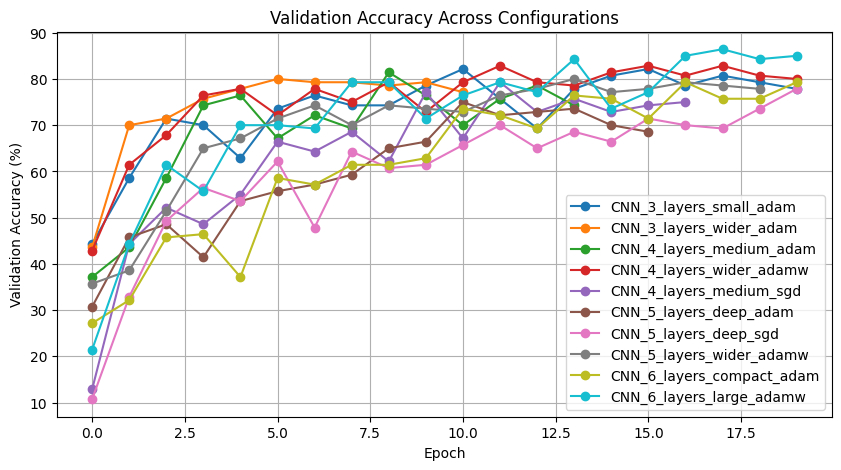

In [24]:

plt.figure(figsize=(10, 5))
for r in all_results:
    plt.plot(np.array(r["history"]["val_acc"]) * 100, marker='o', label=r["name"])
plt.title("Validation Accuracy Across Configurations")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


## The best configuration

In [25]:

best_idx = results_table["Best Val Accuracy (%)"].idxmax()
best_model_name = results_table.loc[best_idx, "Model"]
best_result = next(r for r in all_results if r["name"] == best_model_name)

print("Best configuration:")
display(results_table.iloc[[best_idx]])

best_model = ConfigurableCNN(
    num_classes=num_classes,
    conv_channels=eval(best_result["conv_channels"]),
    dropout=best_result["dropout"],
    fc_units=int(best_result["fc_units"])
).to(device)
best_model.load_state_dict(best_result["model_state_dict"])


Best configuration:


,Rank,Model,Conv Layers,Conv Channels,Dropout,FC Units,Optimizer,Learning Rate,Weight Decay,Best Val Accuracy (%),Best Val Loss,Epochs Ran
0,1,CNN_6_layers_large_adamw,11,"(64, 128, 128, 256, 256, 512)",0.45,512,adamw,0.0004,0.0007,86.43,0.5132,20


<All keys matched successfully>

## Evaluation of the best model on the test set

In [26]:

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate_model(best_model, testloader, criterion, device)

print(f"Best model: {best_model_name}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

if test_acc >= 0.90:
    print("Target reached: accuracy is at least 90%.")
else:
    print("Target not yet reached. Try stronger augmentation, more epochs, or transfer learning.")


Best model: CNN_6_layers_large_adamw
Test Loss: 0.9401
Test Accuracy: 68.67%
Target not yet reached. Try stronger augmentation, more epochs, or transfer learning.


## Confusion matrix for the best model

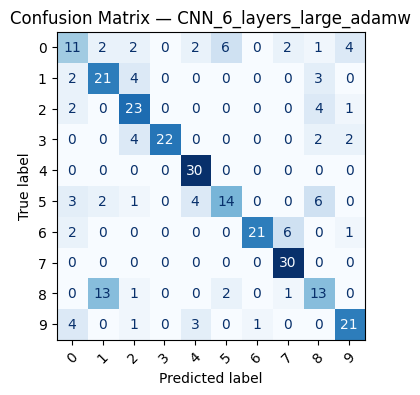

In [32]:

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 4))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


## Classification report

In [28]:

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_df


,precision,recall,f1-score,support
0,0.458333,0.366667,0.407407,30.000000
1,0.552632,0.700000,0.617647,30.000000
2,0.638889,0.766667,0.696970,30.000000
3,1.000000,0.733333,0.846154,30.000000
4,0.769231,1.000000,0.869565,30.000000
5,0.636364,0.466667,0.538462,30.000000
6,0.954545,0.700000,0.807692,30.000000
7,0.769231,1.000000,0.869565,30.000000
8,0.448276,0.433333,0.440678,30.000000
9,0.724138,0.700000,0.711864,30.000000


## The errors of the best network

The most informative errors are the misclassified samples.  
This helps explain:
- which classes are visually similar
- whether the model confuses texture, color, or object shape
- whether the model struggles with scale, viewpoint, or background clutter


In [29]:

@torch.no_grad()
def collect_misclassified_samples(model, dataset, device, max_samples=12):
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    mistakes = []

    model.eval()
    for img, label in loader:
        img = img.to(device)
        label = label.to(device)

        output = model(img)
        pred = output.argmax(dim=1)

        if pred.item() != label.item():
            mistakes.append((img.cpu().squeeze(0), label.item(), pred.item()))
            if len(mistakes) >= max_samples:
                break
    return mistakes

misclassified = collect_misclassified_samples(best_model, test_dataset, device, max_samples=12)
print("Number of displayed misclassified examples:", len(misclassified))


Number of displayed misclassified examples: 12


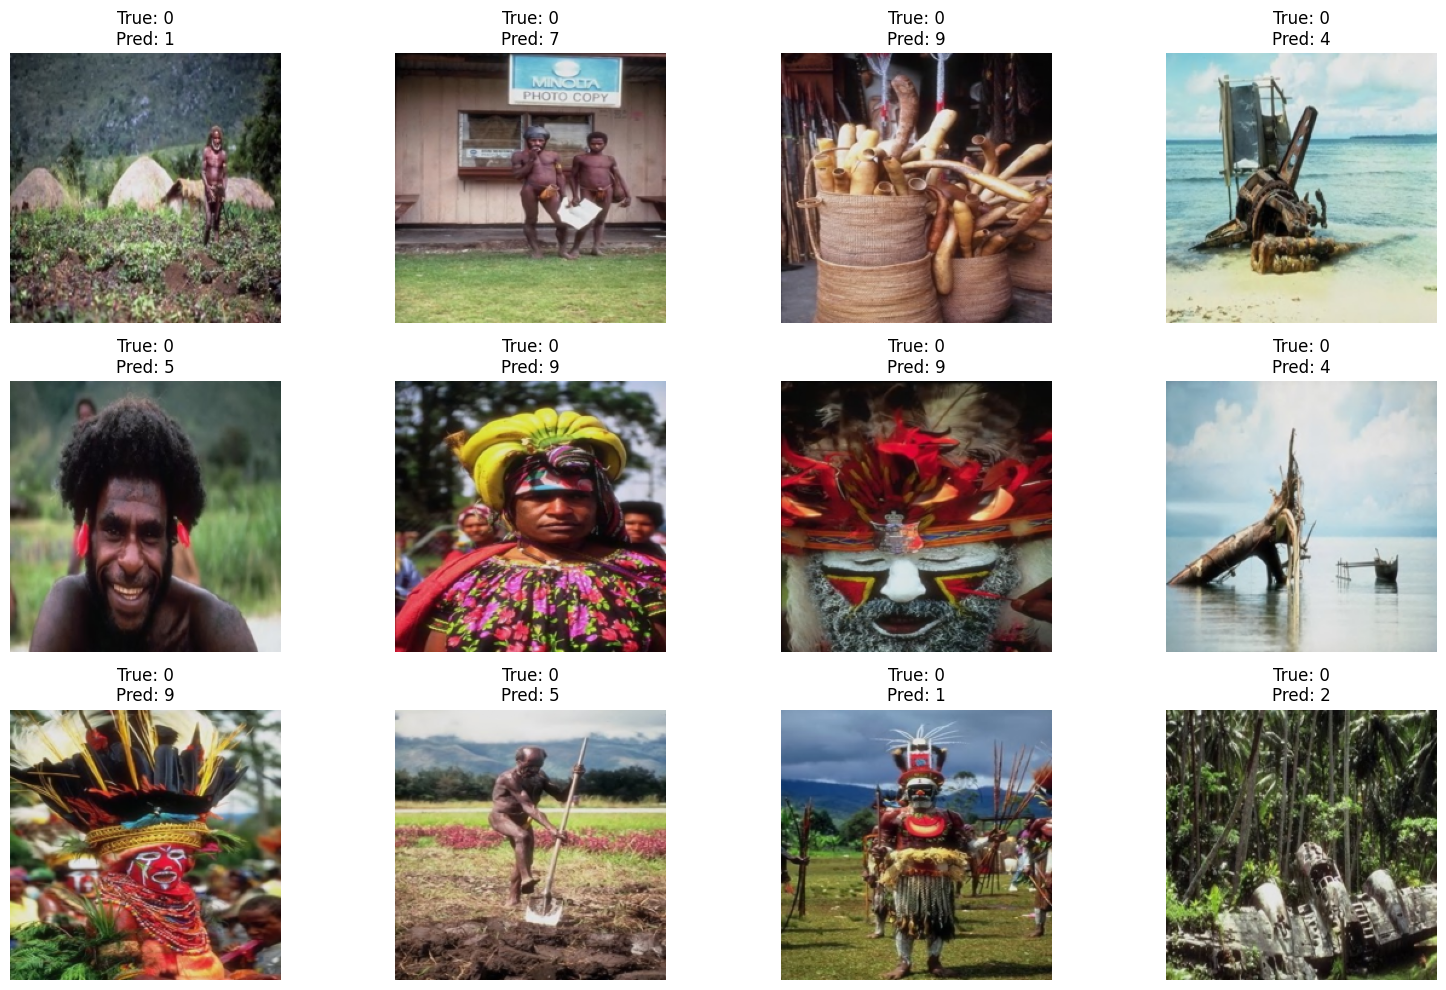

In [30]:

plt.figure(figsize=(16, 10))
for i, (img, true_label, pred_label) in enumerate(misclassified):
    plt.subplot(3, 4, i + 1)
    img = denormalize(img).clamp(0, 1)
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Short analysis
- Models with **more CNN layers** usually learn richer features, but they may overfit if regularization is too weak.
- Increasing the **number of filters** increases model capacity and can improve accuracy, but also raises computation cost.
- **Batch normalization** stabilizes training and often improves convergence.
- **Dropout** helps reduce overfitting.
- **Adam / AdamW** often converge faster, while **SGD** may need more tuning and more epochs.
- The confusion matrix shows which classes are most often confused.
- The misclassified images help explain whether errors are caused by visual similarity, background clutter, poor lighting, or unusual viewpoints.


## Save the best model and the results table

In [31]:

os.makedirs("./outputs", exist_ok=True)

best_model_path = f"./outputs/best_{best_model_name}.pth"
torch.save(best_model.state_dict(), best_model_path)

results_csv_path = "./outputs/cnn_experiment_results.csv"
results_table.to_csv(results_csv_path, index=False)

print(f"Saved best model to: {best_model_path}")
print(f"Saved results table to: {results_csv_path}")


Saved best model to: ./outputs/best_CNN_6_layers_large_adamw.pth
Saved results table to: ./outputs/cnn_experiment_results.csv
